# Introduction to PyTorch

In [ ]:
# Example of PyTorch library
import torch
print(f'PyTorch version: {torch.__version__}')

print(f'Cuda is available: {torch.cuda.is_available()}')
print(f'MPS is available: {torch.backends.mps.is_available()}')


PyTorch version: 2.5.1+cu121
Cuda is available: False
MPS is available: False


## Creating tensors

In [ ]:
# declare two symbolic floating-point scalars
a = torch.tensor(1.5)
b = torch.tensor(2.5)

# create a simple symbolic expression using the add function
c = torch.add(a, b)
print(c)

tensor(4.)


Creating a tensor from a List

In [ ]:
a = torch.FloatTensor([1,2,3,4])
b = torch.FloatTensor([2,3,4,5])

c = a+b
print(c)

tensor([3., 5., 7., 9.])


Creating a tensor from a list of lists

In [ ]:
a = torch.FloatTensor([[1,2],[3,4]])
b = torch.FloatTensor([[2,3],[4,5]])

c = a+b
print(c)

tensor([[3., 5.],
        [7., 9.]])


In [ ]:
import numpy as np

np_a = np.array([[1,2],[3,4]])
np_b = np.array([[2,3],[4,5]])

a = torch.FloatTensor(np_a)
b = torch.FloatTensor(np_b)

c= a+b
print(c)

tensor([[3., 5.],
        [7., 9.]])


In [ ]:
scalar = torch.Tensor(1)
vector = torch.Tensor([1])
matrix = torch.Tensor([[1]])
tensor = torch.Tensor([[[1]]])

print(f"{scalar.ndim}, {vector.ndim}, {matrix.ndim}, {tensor.ndim}")
print(f"{scalar.shape}, {vector.shape}, {matrix.shape}, {tensor.shape}")

1, 1, 2, 3
torch.Size([1]), torch.Size([1]), torch.Size([1, 1]), torch.Size([1, 1, 1])


In [ ]:
t = torch.tensor([[[1, 2, 3, 4],
                   [3, 6, 9, 5],
                   [2, 4, 5, 6]]])

print(f"{t.ndim}, {t.shape}")

3, torch.Size([1, 3, 4])


In [ ]:
t = t.squeeze() # See more later

print(f"{t.ndim}, {t.shape}")

2, torch.Size([3, 4])


## Basic Operations

In [ ]:
c=a*b
print(c)

tensor([[ 2.,  6.],
        [12., 20.]])


In [ ]:
c=a@b
print(c)

tensor([[10., 13.],
        [22., 29.]])


In [ ]:
c = a.sin()
print(c)

c = b.clone()
c.sin_()

print(a)
print(b)
print(c)

tensor([[ 0.8415,  0.9093],
        [ 0.1411, -0.7568]])
tensor([[1., 2.],
        [3., 4.]])
tensor([[2., 3.],
        [4., 5.]])
tensor([[ 0.9093,  0.1411],
        [-0.7568, -0.9589]])


In [ ]:
v=torch.arange(0,11, dtype=float, requires_grad=True)
print(v)

tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.],
       dtype=torch.float64, requires_grad=True)


In [ ]:
v2 = torch.flip(v, [0])
print(v2)

tensor([10.,  9.,  8.,  7.,  6.,  5.,  4.,  3.,  2.,  1.,  0.],
       dtype=torch.float64, grad_fn=<FlipBackward0>)


In [ ]:
vv = v*v2
print(vv)

tensor([ 0.,  9., 16., 21., 24., 25., 24., 21., 16.,  9.,  0.],
       dtype=torch.float64, grad_fn=<MulBackward0>)


# Handling Dimensions


## Squeeze and unsqueeze

In [ ]:
b = a.unsqueeze(dim=0)
print(b)
print(b.shape)

c = a.unsqueeze(dim=1)
print(c)
print(c.shape)

d = a.unsqueeze(dim=2)
print(d)
print(d.shape)

tensor([[[1., 2.],
         [3., 4.]]])
torch.Size([1, 2, 2])
tensor([[[1., 2.]],

        [[3., 4.]]])
torch.Size([2, 1, 2])
tensor([[[1.],
         [2.]],

        [[3.],
         [4.]]])
torch.Size([2, 2, 1])


In [ ]:
f = b.squeeze()
print(f)

tensor([[1., 2.],
        [3., 4.]])


## Views

In [ ]:
x = torch.arange(8).view(2,2,2)
print(x)

tensor([[[0, 1],
         [2, 3]],

        [[4, 5],
         [6, 7]]])


In [ ]:
x2=x.view(4,2)
print(x2)

tensor([[0, 1],
        [2, 3],
        [4, 5],
        [6, 7]])


In [ ]:
x3=x.view(2,4)
print(x3)

tensor([[0, 1, 2, 3],
        [4, 5, 6, 7]])


In [ ]:
x4 = x.view(8)
print(x4)

tensor([0, 1, 2, 3, 4, 5, 6, 7])


# Sampling

In [ ]:
uniform_dist = torch.rand((1,200))

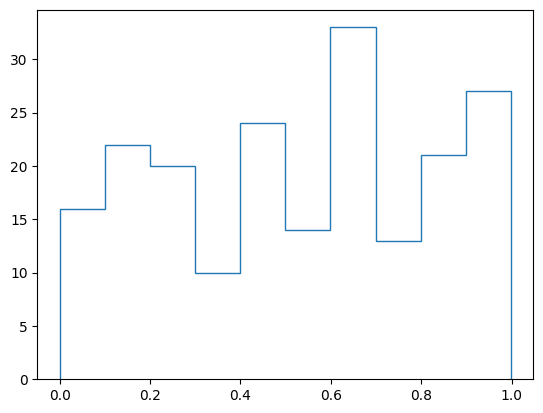

In [ ]:
import matplotlib.pyplot as plt

counts, bins = np.histogram(uniform_dist)
plt.stairs(counts, bins)

In [ ]:
normal_dist = torch.normal(mean=torch.zeros((1,1000)), std=torch.ones((1,1000)))

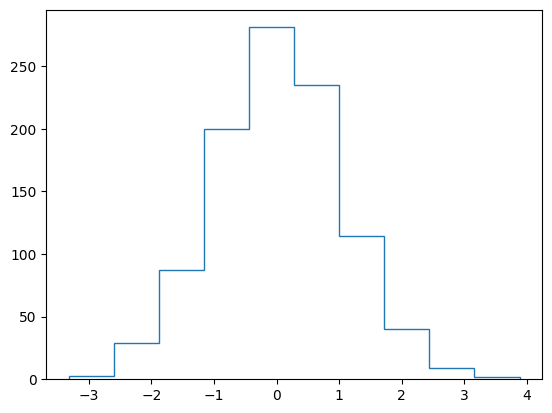

In [ ]:
counts, bins = np.histogram(normal_dist)
plt.stairs(counts, bins)

## Statistical Distributions

In [ ]:
from torch.distributions.categorical import Categorical

In [ ]:
# Suppose that we have a distribution like the following:
probs=torch.FloatTensor([0.4, 0.4, 0.15, 0.05])

# We can create a distribution based on this values
dist = Categorical(probs=probs)
print(dist)

Categorical(probs: torch.Size([4]))


In [ ]:
# We can calculate probabilities for each category:
print(f'Probability distribution: {dist.probs}')

Probability distribution: tensor([0.4000, 0.4000, 0.1500, 0.0500])


In [ ]:
# We can calculate log-probabilities for a certain value:
# - 0 means that a value is certain
# - very low negative values mean that this value is very unexpected
print(f'log(prob(0)): {dist.log_prob(torch.FloatTensor([0]))}')
print(f'log(prob(3)): {dist.log_prob(torch.FloatTensor([3]))}')

log(prob(0)): tensor([-0.9163])
log(prob(3)): tensor([-2.9957])


In [ ]:
# We can also sample entries according to the underlying probability
print(dist.sample())
print(dist.sample())
print(dist.sample())
print(dist.sample())

tensor(0)
tensor(1)
tensor(2)
tensor(1)


In [ ]:
# We can calculate the entropy of an entry as:
entropy = -dist.log_prob(torch.FloatTensor([0]))*dist.probs[0]
print(entropy)

tensor([0.3665])


In [ ]:
# Similarly we can work with other distributions including continuous distributions
# such as the normal distribution
from torch.distributions.normal import Normal
dist = Normal(torch.tensor([1.7]), torch.tensor([0.3]))

# let's see the probability of having
sample = torch.FloatTensor([1.7])#dist.sample()
log_prob = dist.log_prob(sample)
prob = torch.exp(log_prob)

print(f'Value: {sample.item()}: log(prob): {log_prob.item()}, prob: {prob.item()}, entropy: {(-log_prob*prob).item()}')

Value: 1.7000000476837158: log(prob): 0.28503429889678955, prob: 1.3298076391220093, entropy: -0.37904077768325806


### Logits

A typical representation of probability distributions in tensor libraries such as PyTorch are logits. Logits is a function that maps probabilities from the range [0, 1] to real numbers:

$$L=\ln \frac{p}{(1-p)}$$

$$p= \dfrac{1}{(1+e^{-L})}$$

In [ ]:
dist1 = Categorical(probs=torch.FloatTensor([0.3, 0.4, 0.2, 0.1]))
dist2 = Categorical(logits=torch.FloatTensor([-0.8473,-0.4055,-1.3863,-2.196]))
print(dist1.log_prob(torch.arange(4)))
print(dist2.log_prob(torch.arange(4)))


tensor([-1.2040, -0.9163, -1.6094, -2.3026])
tensor([-1.2233, -0.7815, -1.7623, -2.5720])


### Comparing two distributions

In some cases we want to compare how close or far are two distributions (e.g. because we want to converge to a given value). The KL divergence (Kullback-Leibler divergence) allows us to do such comparison. Its value is 0 for two distributions that are equal.

For discrete distributions: $$D_{KL}(P||Q)=\sum_{x \in X} P(x)\ln\dfrac{P(x)}{Q(x)} = \sum_{x \in X} P(x)(\ln(P(x))-\ln(Q(x)))$$

In [ ]:
def kl(dist1, dist2):
    size1 = len(dist1.probs)
    size2 = len(dist2.probs)

    assert size1 == size2

    x = torch.arange(size1)

    return (dist1.probs*(dist1.log_prob(x)-dist2.log_prob(x))).sum()

In [ ]:
kl_div = kl(dist1, dist2)
print(kl_div)

tensor(0.0094)


In [ ]:
dist3 = Categorical(probs=torch.FloatTensor([9.0/25.0, 12.0/25.0, 4.0/25.0]))
dist4 = Categorical(probs=torch.FloatTensor([1.0/3.0, 1.0/3.0, 1.0/3.0]))

print(kl(dist3, dist4))
print(kl(dist4, dist3))

tensor(0.0853)
tensor(0.0975)


## Moving a tensor to a device

Pytorch enables a simple approach to handling the location of a tensor. Note that to perform a certain computation the participating tensors must be on the same device.

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(device)

cpu


In [ ]:
a = a.to(device)
b = b.to(device)

c = a+b

print(c)
print(c.cpu())
print(c.cpu().numpy())

tensor([[[2., 4.],
         [6., 8.]]])
tensor([[[2., 4.],
         [6., 8.]]])
[[[2. 4.]
  [6. 8.]]]


## Gradients

One of the main capabilities of PyTorch is the possibility of computing the gradients of an expresion automatically.

In [ ]:
a = torch.FloatTensor([1,2,3,4])
b = torch.FloatTensor([2,3,4,5])
x = torch.tensor([2,3,4,5], dtype=torch.float32, requires_grad = True)

exp = (a*x+b).sum()
exp.backward()

print(x.grad)
x.grad.zero_()

tensor([1., 2., 3., 4.])


tensor([0., 0., 0., 0.])

In [ ]:
exp = (a*(x*x)+b).sum() # exp' = 2*a*x
exp.backward()

print(x.grad)
x.grad.zero_()

tensor([ 4., 12., 24., 40.])


tensor([0., 0., 0., 0.])

# Optimization

In [ ]:
def func(x):
    return torch.sin(x)*x

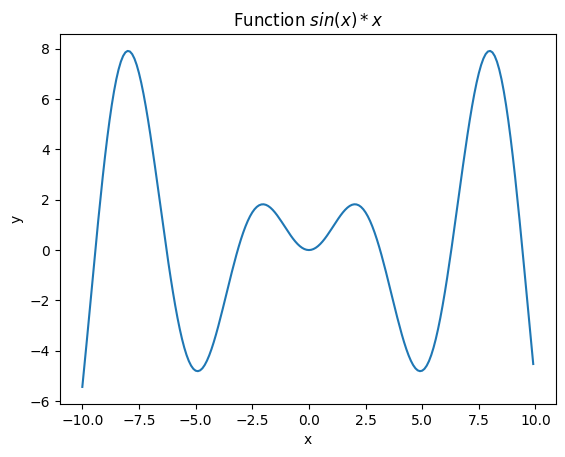

In [ ]:
x = np.arange(-10, 10, 0.1)
y = func(torch.tensor(x))
plt.title("Function $sin(x)*x$")
plt.xlabel("x")
plt.ylabel("y")
plt.plot(x,y.numpy())
plt.show()

In [ ]:
#x = torch.rand(1, 1, device=device, requires_grad=True)
x=torch.FloatTensor([[2.7]])
x.requires_grad = True
print(x)

tensor([[2.7000]], requires_grad=True)


In [ ]:
optimizer = torch.optim.SGD([x], lr=.01, momentum=0.9)

In [ ]:
n_iter = 200  # fix the number of iterations
for it in range(n_iter):
    # re-init the optimizer gradients
    optimizer.zero_grad()
    y = func(x)
    y.backward()
    optimizer.step()

In [ ]:
print(x)

tensor([[4.9131]], requires_grad=True)


In [ ]:
print(x.grad)

tensor([[-0.0003]])


## Modules

In [ ]:
import torch.nn as nn

In [ ]:
x = torch.FloatTensor([1,2,3,4])
model = nn.Linear(4,1)

y = model(x)

print(y)

tensor([-1.6359], grad_fn=<ViewBackward0>)


In [ ]:
print(model)
print(y.item())

Linear(in_features=4, out_features=1, bias=True)
-1.635922908782959


In [ ]:
model = nn.Sequential(*[
    nn.Linear(4, 4),
    nn.ReLU(),
    nn.Linear(4,1)
])

print(model)

Sequential(
  (0): Linear(in_features=4, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=1, bias=True)
)


In [ ]:
y = model(x)
print(y)

tensor([1.3241], grad_fn=<ViewBackward0>)


One important aspect of models in PyTorch is that they are vectorial by default. If we pass multiple values of the correct shape (a.k.a a batch) we will receive an output for each entry.

In [ ]:
x = torch.FloatTensor([[1,2,3,4], [2,3,4,5]])
y= model(x)
print(y)

tensor([[1.3241],
        [1.7478]], grad_fn=<AddmmBackward0>)


## Learning a function

In [ ]:
# Set the random seed for reproducibility
np.random.seed(42)

# Generate angles between 0 and 2*pi
angles = np.random.uniform(low=0, high=2*np.pi, size=(1000,))

# Generate sin values for the angles
sin_values = np.sin(angles)

# Convert the data to PyTorch tensors
inputs = torch.from_numpy(angles).float().unsqueeze(1)
targets = torch.from_numpy(sin_values).float().unsqueeze(1)

In [ ]:
print(inputs)

tensor([[2.3533],
        [5.9735],
        [4.5993],
        [3.7615],
        [0.9803],
        [0.9801],
        [0.3650],
        [5.4423],
        [3.7769],
        [4.4490],
        [0.1293],
        [6.0941],
        [5.2304],
        [1.3342],
        [1.1424],
        [1.1524],
        [1.9116],
        [3.2971],
        [2.7140],
        [1.8298],
        [3.8444],
        [0.8765],
        [1.8356],
        [2.3019],
        [2.8656],
        [4.9334],
        [1.2546],
        [3.2310],
        [3.7223],
        [0.2919],
        [3.8173],
        [1.0714],
        [0.4087],
        [5.9620],
        [6.0672],
        [5.0793],
        [1.9139],
        [0.6137],
        [4.2992],
        [2.7656],
        [0.7668],
        [3.1113],
        [0.2161],
        [5.7134],
        [1.6260],
        [4.1628],
        [1.9585],
        [3.2677],
        [3.4351],
        [1.1615],
        [6.0921],
        [4.8703],
        [5.9030],
        [5.6224],
        [3.7567],
        [5

In [ ]:
# Define the sequential model
model = nn.Sequential(
    nn.Linear(1, 16),
    nn.ReLU(),
    nn.Linear(16, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

In [ ]:
import torch.optim as optim

def train(model):
    # Define the loss function
    loss_fn = nn.MSELoss()

    # Define the optimizer
    optimizer = optim.SGD(model.parameters(), lr=0.01)

    # Set the number of training epochs
    num_epochs = 10000

    # Training loop
    for epoch in range(num_epochs):
        # Missing select some inputs for this batch
        # Forward pass
        outputs = model(inputs)
        loss = loss_fn(outputs, targets)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Print the loss every 100 epochs
        if (epoch+1) % 1000 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item()}')

train(model)

Epoch [1000/10000], Loss: 0.09227088838815689
Epoch [2000/10000], Loss: 0.035022225230932236
Epoch [3000/10000], Loss: 0.011464638635516167
Epoch [4000/10000], Loss: 0.004350415430963039
Epoch [5000/10000], Loss: 0.0020436181221157312
Epoch [6000/10000], Loss: 0.001142332679592073
Epoch [7000/10000], Loss: 0.0007547036511823535
Epoch [8000/10000], Loss: 0.0005609788931906223
Epoch [9000/10000], Loss: 0.0004596903163474053
Epoch [10000/10000], Loss: 0.0004052319854963571


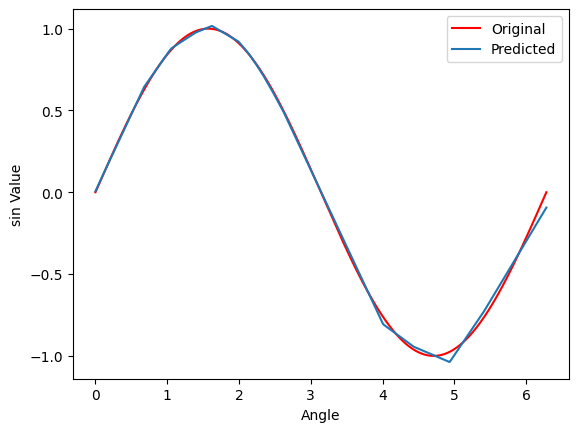

In [ ]:
import matplotlib.pyplot as plt

def test_model(model):
    # Set the model to evaluation mode
    model.eval()

    # Generate angles for testing
    test_angles = torch.linspace(0, 2*np.pi, 1000).unsqueeze(1)

    # Forward pass on test angles
    with torch.no_grad():
        predicted_sin = model(test_angles)
        true_sin = np.sin(test_angles)

    # Convert tensors to numpy arrays
    test_angles = test_angles.numpy()
    predicted_sin = predicted_sin.numpy()

    # Plot the results
    plt.plot(test_angles, true_sin, 'r', label='Original')
    plt.plot(test_angles, predicted_sin, label='Predicted')
    plt.xlabel('Angle')
    plt.ylabel('sin Value')
    plt.legend()
    plt.show()

test_model(model)

### Class-based approach to defining a model

In [ ]:
class Sin_nn(nn.Module):
    def __init__(self):
        super(Sin_nn, self).__init__()
        self.fc1 = nn.Linear(1,16)
        self.fc2 = nn.Linear(16,32)
        self.fc3 = nn.Linear(32,1)

    #This must be implemented
    def forward(self, x):
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        x = torch.relu(x)
        return self.fc3(x)

In [ ]:
model2 = Sin_nn()
train(model2)

Epoch [1000/10000], Loss: 0.09166279435157776
Epoch [2000/10000], Loss: 0.04234682023525238
Epoch [3000/10000], Loss: 0.019227473065257072
Epoch [4000/10000], Loss: 0.008855416439473629
Epoch [5000/10000], Loss: 0.004429647233337164
Epoch [6000/10000], Loss: 0.00252796383574605
Epoch [7000/10000], Loss: 0.0016311542131006718
Epoch [8000/10000], Loss: 0.001158659579232335
Epoch [9000/10000], Loss: 0.000905051187146455
Epoch [10000/10000], Loss: 0.00075382343493402


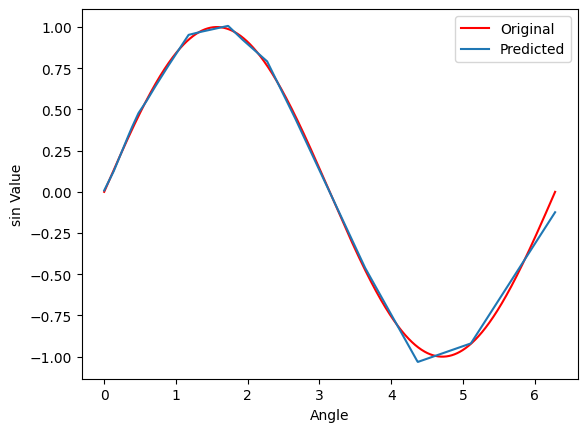

In [ ]:
test_model(model2)

# Saving and reading models

In [ ]:
# Let's ensure that the model is in the CPU
model2.to('cpu')
torch.save(model2.state_dict(), 'model2.pth')

In [ ]:
loaded_model = Sin_nn()

loaded_model.load_state_dict(torch.load('model2.pth'))

loaded_model.eval()
with torch.no_grad():
  print(loaded_model(torch.FloatTensor([np.pi/2])).item())

0.9924664497375488


<ipython-input-62-6f296357e67c>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load('model2.pth'))


# ONNX

ONNX (Open Neural Network Exchange) is an open-source format designed to represent machine learning models in a way that is both framework-agnostic and platform-independent.

Developed by a community of partners including Microsoft, Amazon, Facebook, and others, ONNX provides a common interface that enables models trained in one machine learning framework (such as PyTorch, TensorFlow, or scikit-learn) to be exported and then used for inference in different runtime environments or on different hardware platforms.

This interoperability is particularly valuable for developers and researchers who need to deploy models across various systems or who want to utilize the best aspects of multiple frameworks. ONNX defines a comprehensive set of operations, data types, and neural network structures through a graph-based model representation, facilitating the optimization and execution of models on diverse devices, from cloud-based servers to edge devices.

In [ ]:
!pip install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.8/725.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 83.0 MB/s eta 0:00:00


In [ ]:
x = torch.rand(1).float()
onnx_export = torch.onnx.dynamo_export(model2, x)
onnx_export.save('model.onnx')

/usr/local/lib/python3.10/dist-packages/onnxscript/converter.py:820: FutureWarning: 'onnxscript.values.Op.param_schemas' is deprecated in version 0.1 and will be removed in the future. Please use '.op_signature' instead.
  param_schemas = callee.param_schemas()
/usr/local/lib/python3.10/dist-packages/onnxscript/converter.py:820: FutureWarning: 'onnxscript.values.OnnxFunction.param_schemas' is deprecated in version 0.1 and will be removed in the future. Please use '.op_signature' instead.
  param_schemas = callee.param_schemas()
/usr/local/lib/python3.10/dist-packages/torch/onnx/_internal/_exporter_legacy.py:116: UserWarning: torch.onnx.dynamo_export only implements opset version 18 for now. If you need to use a different opset version, please register them with register_custom_op.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torch/onnx/_internal/fx/onnxfunction_dispatcher.py:503: FutureWarning: 'onnxscript.values.TracedOnnxFunction.param_schemas' is deprecated in version 0.

Applied 3 of general pattern rewrite rules.


In [ ]:
!pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 3.4 MB/s eta 0:00:00


In [ ]:
import onnxruntime as ort

session = ort.InferenceSession('model.onnx')

In [ ]:
input_name = session.get_inputs()[0].name
print(input_name)

l_x_


In [ ]:
output = session.run(None, {input_name: [np.pi/2]})
print (output)

[array([0.99246645], dtype=float32)]
